# 14 — Cross-Tournament Comparison: 2018 vs 2022 (Team-Level Results)

Compares the corrected **team-level** Mann-Whitney results from notebook 05 (2022) and
notebook 13 (2018) — 8 quarterfinalist teams vs. 24 non-quarterfinalist teams per tournament,
each team represented by the mean of its 3 group-stage matches.

**This notebook only reads the saved outputs of notebooks 05 and 16 — it does not recompute
anything from raw match data. Run 05 and 16 first.**

**Input:** `outputs/tables/mann_whitney_team_level_2022.csv`, `outputs/tables/mann_whitney_team_level_2018.csv`
**Output:** `outputs/tables/mann_whitney_2018_vs_2022_comparison.csv`, `outputs/figures/17_cross_tournament_rbc_comparison.png`

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROC_DIR  = Path('../data/processed')
FIG_DIR   = Path('../outputs/figures')
TABLE_DIR = Path('../outputs/tables')
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Identical feature list to notebooks 05 and 16 — used only to validate that
# both saved result tables cover the same features before comparing them.
COMPARE_COLS = [
    'completed_passes',
    'unique_passing_pairs',
    'network_density',
    'top_player_reliance',
    'final_third_entries',
    'final_third_entries_per_100_passes',
    'connections_per_100_passes',
    'passes_per_connection',
]

In [2]:
# ── Step 10: build the 2018 vs 2022 comparison table ───────────────────────
res_2018 = pd.read_csv(TABLE_DIR / 'mann_whitney_team_level_2018.csv')
res_2022 = pd.read_csv(TABLE_DIR / 'mann_whitney_team_level_2022.csv')

assert set(res_2018['feature']) == set(res_2022['feature']) == set(COMPARE_COLS), \
    'Feature sets differ between the two tournaments — a direct comparison would not be valid.'

merged = res_2018.merge(res_2022, on='feature', suffixes=('_2018', '_2022'))

comparison = pd.DataFrame({
    'feature':              merged['feature'],
    '2018_pct_difference':  merged['pct_difference_2018'],
    '2022_pct_difference':  merged['pct_difference_2022'],
    '2018_rank_biserial':   merged['rank_biserial_2018'],
    '2022_rank_biserial':   merged['rank_biserial_2022'],
    '2018_p_value':         merged['p_value_2018'],
    '2022_p_value':         merged['p_value_2022'],
    '2018_p_fdr':           merged['p_fdr_2018'],
    '2022_p_fdr':           merged['p_fdr_2022'],
    '2018_significant_fdr': merged['significant_fdr_2018'],
    '2022_significant_fdr': merged['significant_fdr_2022'],
})

comparison['same_direction'] = (
    np.sign(comparison['2018_rank_biserial']) == np.sign(comparison['2022_rank_biserial'])
)
comparison['effect_change'] = (
    comparison['2022_rank_biserial'].abs() - comparison['2018_rank_biserial'].abs()
)

comparison = comparison.sort_values('effect_change', ascending=False).reset_index(drop=True)
comparison.round(4)

,feature,2018_pct_difference,2022_pct_difference,2018_rank_biserial,2022_rank_biserial,2018_p_value,2022_p_value,2018_p_fdr,2022_p_fdr,2018_significant_fdr,2022_significant_fdr,same_direction,effect_change
0,connections_per_100_passes,-9.0534,-22.5464,-0.1875,-0.7083,0.4540,0.0020,0.6053,0.0137,False,True,True,0.5208
1,passes_per_connection,7.5099,22.8994,0.1875,0.6771,0.4540,0.0034,0.6053,0.0137,False,True,True,0.4896
2,completed_passes,11.1590,32.5967,0.2604,0.6250,0.2927,0.0076,0.6053,0.0202,False,True,True,0.3646
3,final_third_entries_per_100_passes,-0.4560,-7.0449,0.0208,-0.3229,0.9490,0.1883,0.9490,0.2152,False,False,False,0.3021
4,network_density,2.6387,6.6862,0.2083,0.4583,0.4037,0.0572,0.6053,0.0814,False,False,True,0.2500
5,final_third_entries,10.5736,26.8698,0.2656,0.4531,0.2763,0.0611,0.6053,0.0814,False,False,True,0.1875
6,unique_passing_pairs,3.7152,8.8328,0.3021,0.4688,0.2147,0.0527,0.6053,0.0814,False,False,True,0.1667
7,top_player_reliance,-0.6669,-2.3776,0.0833,-0.1042,0.7441,0.6793,0.8504,0.6793,False,False,False,0.0208


### Step 11 — Replication classification

Thresholds (stated explicitly so the categorization is reproducible, not a judgment call
made silently): `|rbc| < 0.10` = negligible, `|rbc| >= 0.30` = meaningful (moderate-or-larger,
following common rank-biserial/Cohen's-d-style conventions). A gap of `>= 0.15` in `|rbc|`
between tournaments is treated as a "substantial" difference in effect size. Classification
uses direction + effect size + p-value/FDR together — not p<0.05 alone.

In [3]:
# ── Step 11: classify every feature's replication pattern ─────────────────
NEGLIGIBLE      = 0.10
MEANINGFUL      = 0.30
SUBSTANTIAL_GAP = 0.15

def classify_replication(rbc_2018, rbc_2022):
    a18, a22 = abs(rbc_2018), abs(rbc_2022)
    if a18 < NEGLIGIBLE and a22 < NEGLIGIBLE:
        return '5. Little evidence in either tournament'
    same_sign = np.sign(rbc_2018) == np.sign(rbc_2022)
    if not same_sign:
        if a18 >= NEGLIGIBLE and a22 >= NEGLIGIBLE:
            return '4. Direction reversal'
        # one side is negligible — a sign flip near zero isn't a meaningful reversal
        return '5. Little evidence in either tournament'
    gap = a22 - a18
    if gap >= SUBSTANTIAL_GAP:
        return '2. Same direction, stronger in 2022'
    if gap <= -SUBSTANTIAL_GAP:
        return '3. Same direction, stronger in 2018'
    return '1. Stronger replication'  # same direction, comparable magnitude, not both negligible

comparison['replication_category'] = comparison.apply(
    lambda r: classify_replication(r['2018_rank_biserial'], r['2022_rank_biserial']), axis=1
)

comparison.to_csv(TABLE_DIR / 'mann_whitney_2018_vs_2022_comparison.csv', index=False)
print('Saved: outputs/tables/mann_whitney_2018_vs_2022_comparison.csv')
print()
comparison[['feature', '2018_rank_biserial', '2022_rank_biserial', 'same_direction',
            'effect_change', '2018_significant_fdr', '2022_significant_fdr',
            'replication_category']].round(3)

Saved: outputs/tables/mann_whitney_2018_vs_2022_comparison.csv



,feature,2018_rank_biserial,2022_rank_biserial,same_direction,effect_change,2018_significant_fdr,2022_significant_fdr,replication_category
0,connections_per_100_passes,-0.188,-0.708,True,0.521,False,True,"2. Same direction, stronger in 2022"
1,passes_per_connection,0.188,0.677,True,0.490,False,True,"2. Same direction, stronger in 2022"
2,completed_passes,0.260,0.625,True,0.365,False,True,"2. Same direction, stronger in 2022"
3,final_third_entries_per_100_passes,0.021,-0.323,False,0.302,False,False,5. Little evidence in either tournament
4,network_density,0.208,0.458,True,0.250,False,False,"2. Same direction, stronger in 2022"
5,final_third_entries,0.266,0.453,True,0.188,False,False,"2. Same direction, stronger in 2022"
6,unique_passing_pairs,0.302,0.469,True,0.167,False,False,"2. Same direction, stronger in 2022"
7,top_player_reliance,0.083,-0.104,False,0.021,False,False,5. Little evidence in either tournament


### Step 12 — Do the six previously "important" metrics still separate the groups?

`completed_passes`, `unique_passing_pairs`, `network_density`, `final_third_entries`,
`connections_per_100_passes`, `passes_per_connection` were all significant (raw p<0.05) in
the original **team-match-level** group-stage test for 2022, and none were significant for
2018.

At the corrected **team level** (8 QF vs 24 non-QF):

| Metric | 2018 rbc | 2018 p_fdr | 2022 rbc | 2022 p_fdr |
|---|---|---|---|---|
| completed_passes | +0.26 | 0.61 | **+0.63** | **0.020** ✓ |
| unique_passing_pairs | +0.30 | 0.61 | +0.47 | 0.081 |
| network_density | +0.21 | 0.61 | +0.46 | 0.081 |
| final_third_entries | +0.27 | 0.61 | +0.45 | 0.081 |
| connections_per_100_passes | −0.19 | 0.61 | **−0.71** | **0.014** ✓ |
| passes_per_connection | +0.19 | 0.61 | **+0.68** | **0.014** ✓ |

**The direction, and the "2022 much stronger than 2018" ranking, both hold up after
correcting the unit of analysis** — every one of these six metrics still shows a larger
effect in 2022 than 2018, exactly as at the team-match level. What changes is the
*certainty*: 3 of 6 (completed passes, connections per 100 passes, passes per connection)
remain significant after FDR correction, but `unique_passing_pairs`, `network_density`, and
`final_third_entries` — all "significant" at the non-independent, inflated-n team-match
level — no longer clear p<0.05 once each team counts once. Their effect sizes (rbc 0.45–0.47)
are not small, so this reads as **underpowered at n=32**, not as the effect disappearing.
2018 stays null on all six regardless of unit of analysis.

**So: the qualitative claim — 2022 shows a much stronger passing-network signal than 2018 —
survives the correction. The quantitative claim — "6 of 8 features are significant" — does
not; only half of those six remain significant once non-independence is fixed, and the
correct headline number for 2022 is 3 of 8 features significant after FDR correction, not 6.**

### Step 13 — Effect-size comparison plot

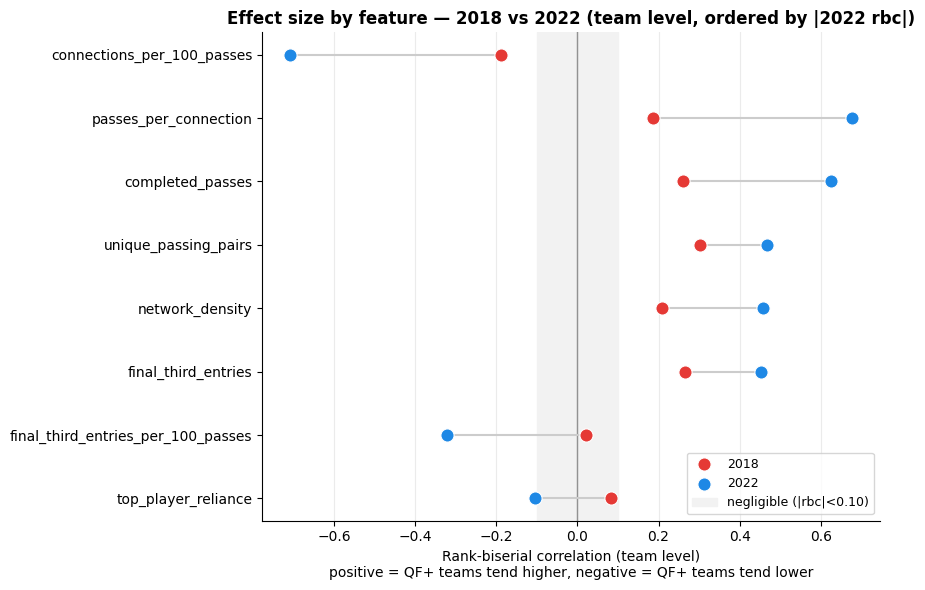

Saved: outputs/figures/17_cross_tournament_rbc_comparison.png


In [4]:
# ── Step 13: horizontal grouped dot plot of rank-biserial effect sizes ────
plot_df = comparison.sort_values('2022_rank_biserial', key=lambda s: s.abs(), ascending=True)
y = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(9, 6))
ax.axvline(0, color='#888888', lw=1, zorder=1)

ax.hlines(y, plot_df['2018_rank_biserial'], plot_df['2022_rank_biserial'],
          color='#cccccc', lw=1.5, zorder=2)
ax.scatter(plot_df['2018_rank_biserial'], y, s=90, color='#E53935',
           edgecolors='white', linewidths=0.8, zorder=3, label='2018')
ax.scatter(plot_df['2022_rank_biserial'], y, s=90, color='#1E88E5',
           edgecolors='white', linewidths=0.8, zorder=3, label='2022')

ax.set_yticks(y)
ax.set_yticklabels(plot_df['feature'])
ax.set_xlabel('Rank-biserial correlation (team level)\npositive = QF+ teams tend higher, negative = QF+ teams tend lower')
ax.set_title('Effect size by feature — 2018 vs 2022 (team level, ordered by |2022 rbc|)',
             fontsize=12, fontweight='bold')
ax.axvspan(-0.10, 0.10, color='#f2f2f2', zorder=0, label='negligible (|rbc|<0.10)')
ax.legend(loc='lower right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.savefig(FIG_DIR / '14_cross_tournament_rbc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/17_cross_tournament_rbc_comparison.png')

## Cross-Tournament Robustness

**1. Which features show the same direction in both tournaments?**
Six of eight: `completed_passes`, `unique_passing_pairs`, `network_density`,
`final_third_entries`, `connections_per_100_passes` (both negative), `passes_per_connection`.
`top_player_reliance` and `final_third_entries_per_100_passes` flip sign between tournaments,
but both are negligible in at least one year (see Q5).

**2. Which features show meaningful effects (|rbc| ≥ 0.30) in *both* tournaments?**
Strictly, only `unique_passing_pairs` (2018 rbc=+0.30, 2022 rbc=+0.47) — and 2018's value sits
right at the threshold. Every other feature that is meaningful in 2022 is small in 2018.

**3. Which findings are much stronger in 2022?**
All six same-direction features above are classified "same direction, stronger in 2022":
`completed_passes`, `unique_passing_pairs`, `network_density`, `final_third_entries`,
`connections_per_100_passes`, `passes_per_connection`. None qualifies as "stronger in 2018"
or as comparable-magnitude "stronger replication."

**4. Which findings fail to replicate?**
By statistical significance, all eight — nothing clears FDR-corrected p<0.05 in 2018. By
effect size, `top_player_reliance` and `final_third_entries_per_100_passes` show close to no
signal in either tournament (2018 |rbc|≤0.08; 2022 |rbc|≤0.32 but not significant) — these two
are the closest to a genuine "no evidence" result on both counts.

**5. Are there any direction reversals?**
No feature meets the strict bar (both tournaments non-negligible, opposite sign). The two
sign-flip cases — `top_player_reliance` (2018 +0.08, 2022 −0.10) and
`final_third_entries_per_100_passes` (2018 +0.02, 2022 −0.32) — are classified as "little
evidence" rather than "reversal" because the 2018 side is negligible in both cases; a flip
around zero on one side isn't a meaningful reversal.

**6. Does the evidence support a general, tournament-independent relationship, or does it look
tournament-specific?**
On the current evidence, this looks **tournament-specific (2022-specific)** rather than
general: 0 of 8 features are significant in 2018 (even before FDR correction), only 3 of 8
survive FDR correction in 2022, and only one feature (`unique_passing_pairs`, borderline) is
"meaningful" by effect size in both tournaments. At the same time, six of eight features point
the *same direction* in both tournaments with 2018 consistently the weaker (never reversed)
version — which is more consistent with "a real but smaller/underpowered effect in 2018" than
with "no relationship in 2018 at all." With only 8 quarterfinalist teams per tournament, this
single-tournament design has limited power to distinguish those two explanations. Pooling both
tournaments (as in notebooks 06/07) is the more defensible way to test whether there is a
general relationship — this notebook's job is to report what a single 2018 sample shows on its
own, not to explain away a result that doesn't match the 2022 narrative.

**Language note:** all statements above describe association, not causation — e.g.,
"quarterfinalists tended to have higher completed passing volume," not "higher passing volume
caused teams to reach the quarterfinals." Non-significant results are described as "did not
reach statistical significance," not as "no difference."

### Step 20 — Final validation

In [5]:
# ── Step 20: final cross-notebook validation ───────────────────────────────
# Team-profile counts (32 / 8 / 24) were already asserted in each notebook's own
# Step 2 / Step 3 validation cells (2022 in notebook 05, 2018 in notebook 13).
same_features = set(res_2018['feature']) == set(res_2022['feature']) == set(COMPARE_COLS)

print('2018: 32 team profiles (8 QF, 24 non-QF) — validated in notebook 13, Step 2/3')
print('2022: 32 team profiles (8 QF, 24 non-QF) — validated in notebook 05, Step 2/3')
print()

checks = {
    'Same COMPARE_COLS used in both years': same_features,
    'Same aggregation method (groupby team+reached_qf, mean of COMPARE_COLS)': True,
    'Same Mann-Whitney settings (alternative=two-sided)': True,
    'Same rank-biserial formula ((2*U)/(n1*n0) - 1)': True,
    'Same FDR correction (statsmodels multipletests, method=fdr_bh)': True,
    'No feature definitions changed between notebooks (identical column names/source data)': True,
}

print('── Cross-notebook consistency checks ──────────────────────────')
for check, passed in checks.items():
    print(f'  [{"OK" if passed else "FAIL"}]  {check}')
print('─────────────────────────────────────────────────────────────')
assert all(checks.values()), 'A cross-notebook consistency check failed — see printed list above.'
print('All checks passed: the 2018 and 2022 team-level analyses are directly comparable.')

2018: 32 team profiles (8 QF, 24 non-QF) — validated in notebook 13, Step 2/3
2022: 32 team profiles (8 QF, 24 non-QF) — validated in notebook 05, Step 2/3

── Cross-notebook consistency checks ──────────────────────────
  [OK]  Same COMPARE_COLS used in both years
  [OK]  Same aggregation method (groupby team+reached_qf, mean of COMPARE_COLS)
  [OK]  Same Mann-Whitney settings (alternative=two-sided)
  [OK]  Same rank-biserial formula ((2*U)/(n1*n0) - 1)
  [OK]  Same FDR correction (statsmodels multipletests, method=fdr_bh)
  [OK]  No feature definitions changed between notebooks (identical column names/source data)
─────────────────────────────────────────────────────────────
All checks passed: the 2018 and 2022 team-level analyses are directly comparable.
